In [1]:
import os
import cv2
import torch           #imports and character mapping
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Character set and mappings
chars = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}

In [2]:
import numpy as np

def preprocess_image(path, img_size=(128, 64)):
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"Failed to load image at {path}")

    # 1. Otsu's thresholding for binarization
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. Remove horizontal lines (adjust kernel size as needed)
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
    detected_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=1)
    no_lines = cv2.subtract(thresh, detected_lines)

    # 3. Remove small noise with morphological opening
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    opened = cv2.morphologyEx(no_lines, cv2.MORPH_OPEN, kernel, iterations=1)

    # 4. Median blur for further denoising
    denoised = cv2.medianBlur(opened, 3)

    # 5. Optional: Sharpen the image
    sharpen_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
    sharpened = cv2.filter2D(denoised, -1, sharpen_kernel)

    # 6. Resize to target size
    final = cv2.resize(sharpened, img_size)
    return final

In [3]:
# ...existing code...
from torch.utils.data import random_split

# Build labels_dict from filenames                  #dataset preparation
img_dir = "A:/Datasets/samples/"
labels_dict = {}
for fname in os.listdir(img_dir):
    if fname.endswith(".png"):
        label_str = ''.join([c for c in os.path.splitext(fname)[0] if c.isalnum()]).upper()
        label_idx = [char2idx[c] for c in label_str]
        labels_dict[fname] = label_idx

from torch.utils.data import Dataset

class OCRDataset(Dataset):
    def __init__(self, img_dir, labels_dict, img_size=(128, 64)):
        self.img_dir = img_dir
        self.labels_dict = labels_dict
        self.img_size = img_size
        self.filenames = list(labels_dict.keys())

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        img_path = os.path.join(self.img_dir, img_name)
        # Preprocess image
        img = preprocess_image(img_path, self.img_size)
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0  # (1, H, W), normalized
        label = torch.tensor(self.labels_dict[img_name], dtype=torch.long)
        return img, label
    
# Create the full dataset
full_dataset = OCRDataset(img_dir, labels_dict)

# Split into train and val
total_size = len(full_dataset)
val_size = int(0.1 * total_size)  # 10% for validation
train_size = total_size - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=True, num_workers=0)

In [4]:

    class CRNN(nn.Module):
        def __init__(self, num_classes, hidden_size=256):
            super(CRNN, self).__init__()
    
            # CNN feature extractor
            self.cnn = nn.Sequential(
                nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),  # H/2, W/2
    
                nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),  # H/4, W/4
            )
    
            # Dummy forward pass to infer feature size
            with torch.no_grad():
                dummy = torch.zeros(1, 1, 64, 128)   # (B,C,H,W)
                feat = self.cnn(dummy)              # (1,C,H',W')
                _, C, H, W = feat.size()
                self.rnn_input_size = C * H         # flatten across H
    
            # BiLSTM
            self.rnn = nn.LSTM(
                input_size=self.rnn_input_size,
                hidden_size=hidden_size,
                num_layers=2,
                bidirectional=True,
                batch_first=True
            )
    
            # Fully connected
            self.fc = nn.Linear(hidden_size * 2, num_classes)  # 2 for bidirectional
    
        def forward(self, x):
            B, C, H, W = x.size()  # (B,1,64,128)
    
            # CNN
            x = self.cnn(x)        # (B,C,H',W')
    
            # Reshape for RNN
            B, C, H, W = x.size()
            x = x.permute(0, 3, 1, 2)          # (B,W,C,H)
            x = x.contiguous().view(B, W, C*H) # (B,W,features)
    
            # RNN
            x, _ = self.rnn(x)    # (B,W,hidden*2)
    
            # FC
            x = self.fc(x)        # (B,W,num_classes)
            return x

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"                 
num_classes = len(idx2char) + 1  # +1 for CTC blank
model = CRNN(num_classes=num_classes).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)                          #CTC Loss, Optimizer, and Decoder
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def ctc_greedy_decoder(logits, idx2char):
    preds = logits.argmax(2).cpu().numpy()
    results = []
    for seq in preds:
        prev = -1
        s = ""
        for p in seq:
            if p != prev and p != 0:
                s += idx2char[p]
            prev = p
        results.append(s)
    return results

In [6]:
# Sequence accuracy (exact match)
def sequence_accuracy(preds, targets, idx2char):
    correct = 0
    total = len(preds)
    for i in range(total):
        gt = "".join([idx2char[c.item()] for c in targets[i] if c.item() != 0])
        if preds[i] == gt:
            correct += 1
    return correct / total if total > 0 else 0

# Character accuracy (per-character match)
def char_accuracy(preds, targets, idx2char):
    correct, total = 0, 0
    for i in range(len(preds)):
        gt = "".join([idx2char[c.item()] for c in targets[i] if c.item() != 0])
        for p, g in zip(preds[i], gt):
            if p == g:
                correct += 1
        total += max(len(preds[i]), len(gt))
    return correct / total if total > 0 else 0


import editdistance

# Character Error Rate (CER)
def cer(preds, targets, idx2char):
    total_edits, total_chars = 0, 0
    for i in range(len(preds)):
        gt = "".join([idx2char[c.item()] for c in targets[i] if c.item() != 0])
        total_edits += editdistance.eval(preds[i], gt)
        total_chars += len(gt)
    return total_edits / total_chars if total_chars > 0 else 0

Epoch 1/15 | Loss: 4.0458
Validation set size: 103

Sample predictions:
GT: GD8FB | Pred: 
GT: NBMX7 | Pred: 
GT: 55Y2M | Pred: 
GT: YEYN4 | Pred: 
GT: NFD8G | Pred: 
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0000
Validation CER: 1.0000


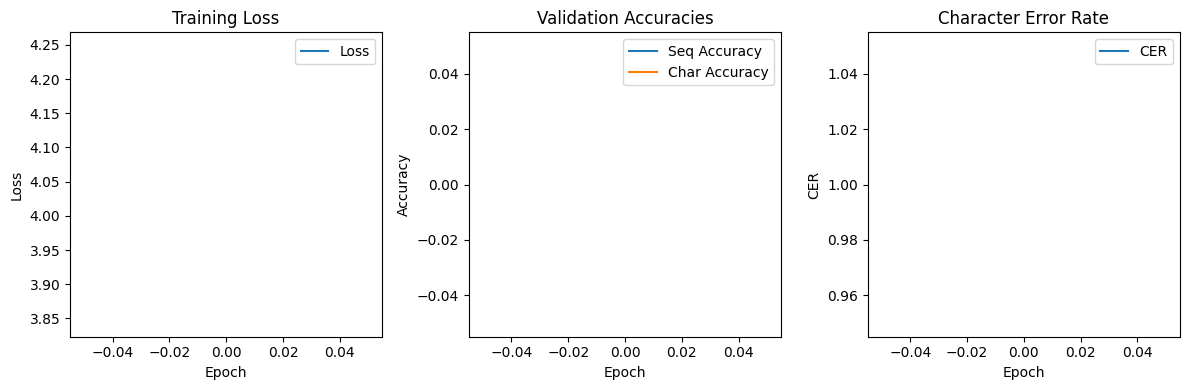

Epoch 2/15 | Loss: 3.2871
Validation set size: 103

Sample predictions:
GT: MX8BB | Pred: 
GT: 2N73F | Pred: 
GT: YCMCW | Pred: 
GT: C3572 | Pred: 
GT: 5MF7C | Pred: 
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0000
Validation CER: 1.0000


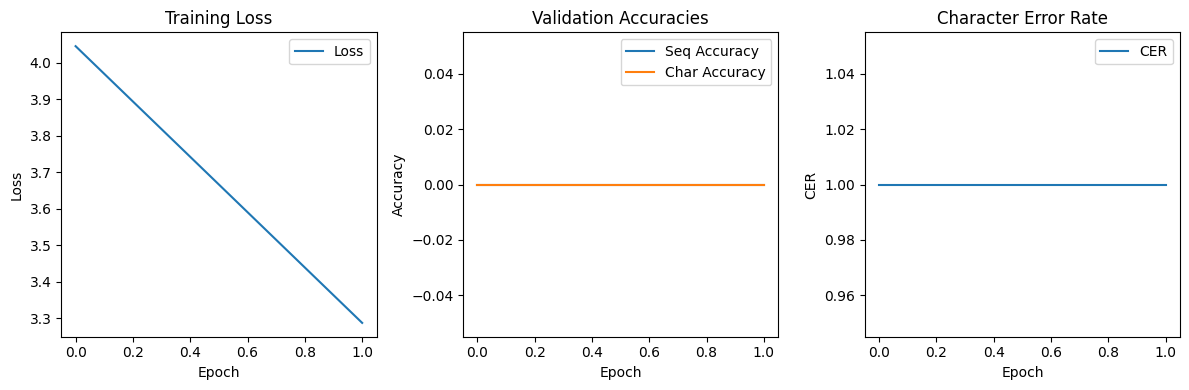

Epoch 3/15 | Loss: 3.2844
Validation set size: 103

Sample predictions:
GT: YCNFC | Pred: 
GT: 55Y2M | Pred: 
GT: B84XC | Pred: 
GT: E2MG2 | Pred: 
GT: N7ENN | Pred: 
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0000
Validation CER: 1.0000


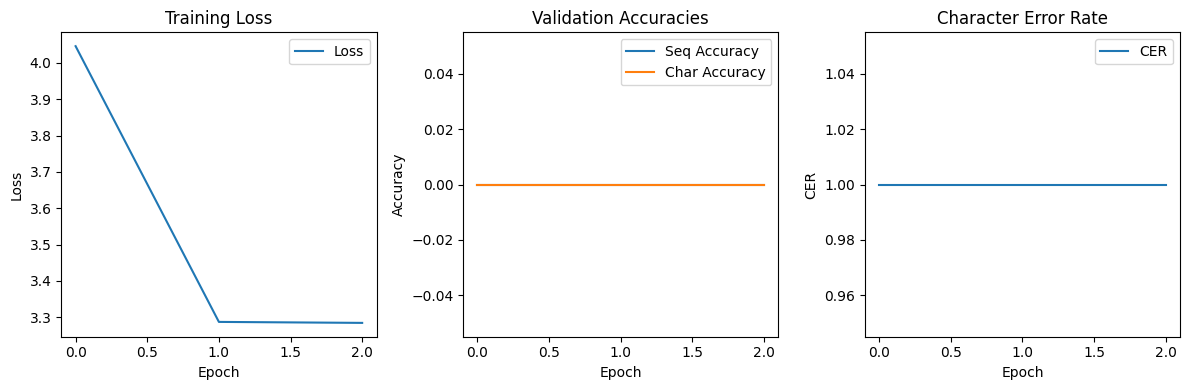

Epoch 4/15 | Loss: 3.2746
Validation set size: 103

Sample predictions:
GT: C55C6 | Pred: 
GT: NXC83 | Pred: 
GT: EPPG3 | Pred: 
GT: CM6YB | Pred: 
GT: YEYN4 | Pred: 
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0000
Validation CER: 1.0000


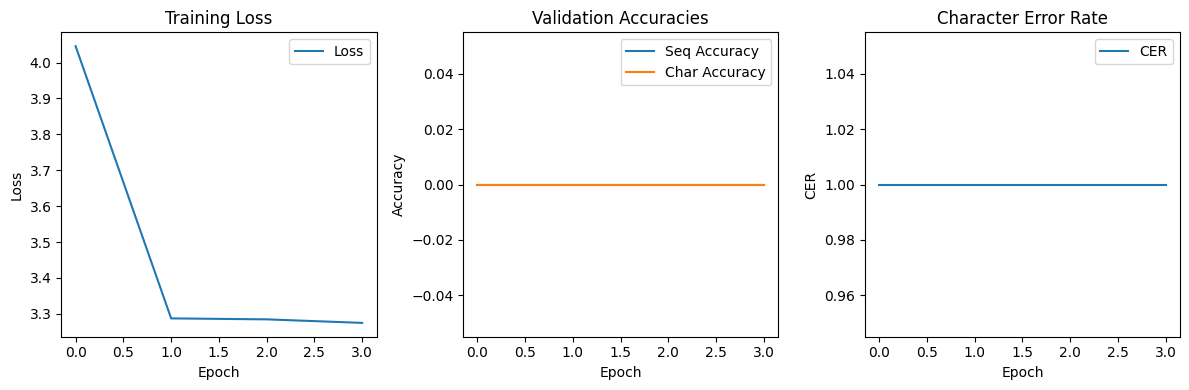

Epoch 5/15 | Loss: 3.2730
Validation set size: 103

Sample predictions:
GT: 4F8YP | Pred: 
GT: 3BX86 | Pred: 
GT: 8NPD5 | Pred: 
GT: 4N2YG | Pred: 
GT: DDPYB | Pred: 
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0000
Validation CER: 1.0000


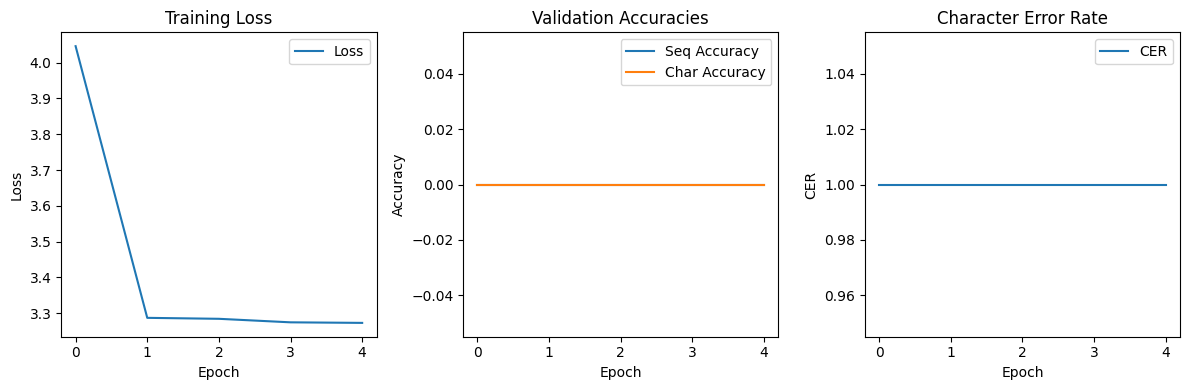

Epoch 6/15 | Loss: 3.2649
Validation set size: 103

Sample predictions:
GT: Y48C3 | Pred: 
GT: CM6YB | Pred: 
GT: CDFEN | Pred: 
GT: 47E4P | Pred: 
GT: W8BNX | Pred: 
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0000
Validation CER: 1.0000


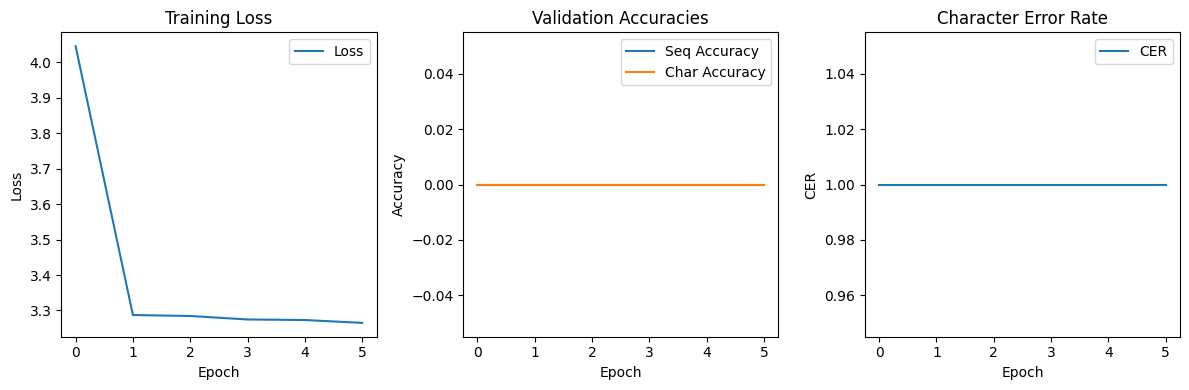

Epoch 7/15 | Loss: 3.2445
Validation set size: 103

Sample predictions:
GT: E667X | Pred: 
GT: N8PFE | Pred: 
GT: NN4WX | Pred: 
GT: B84XC | Pred: 
GT: NXCMN | Pred: 
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0000
Validation CER: 1.0000


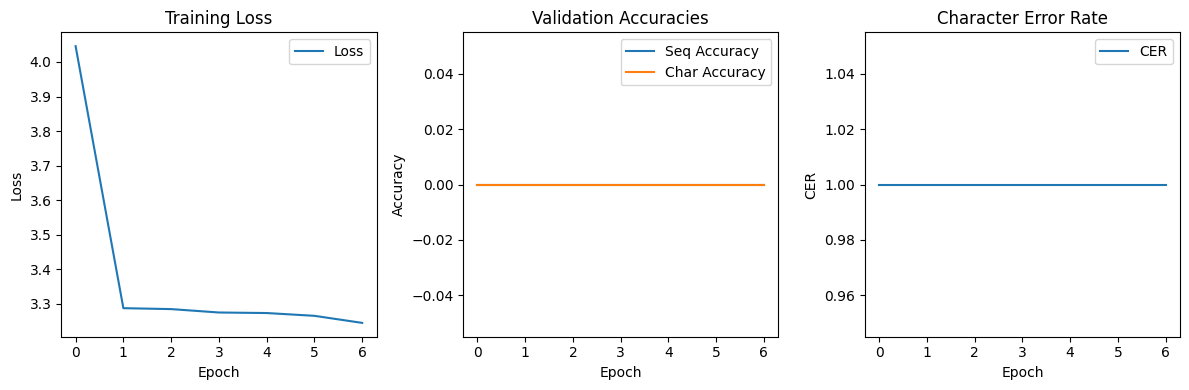

Epoch 8/15 | Loss: 3.1059
Validation set size: 103

Sample predictions:
GT: YW667 | Pred: 
GT: M8GMX | Pred: 
GT: 556WD | Pred: 
GT: CCN2X | Pred: 
GT: PYBEE | Pred: 
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0000
Validation CER: 1.0000


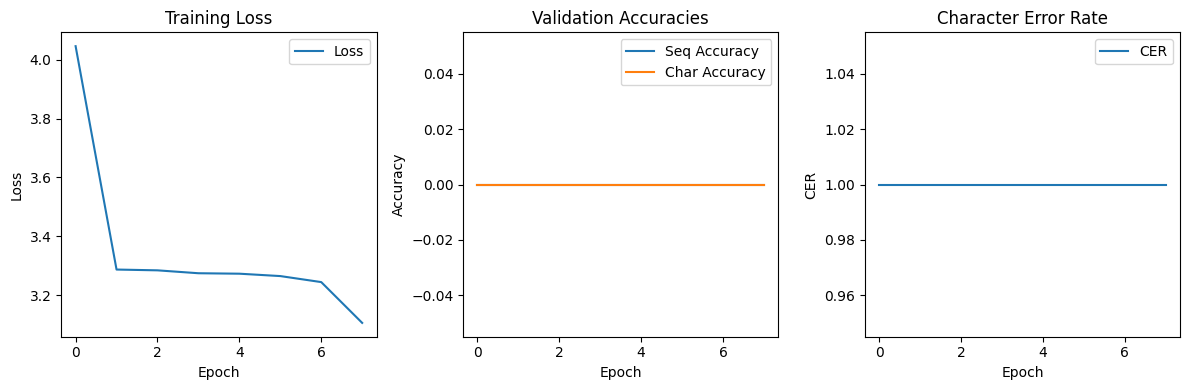

Epoch 9/15 | Loss: 2.7383
Validation set size: 103

Sample predictions:
GT: 7B4BM | Pred: 
GT: 55Y2M | Pred: 
GT: MN5C4 | Pred: 
GT: PDYC8 | Pred: 
GT: NNF8B | Pred: 
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0000
Validation CER: 1.0000


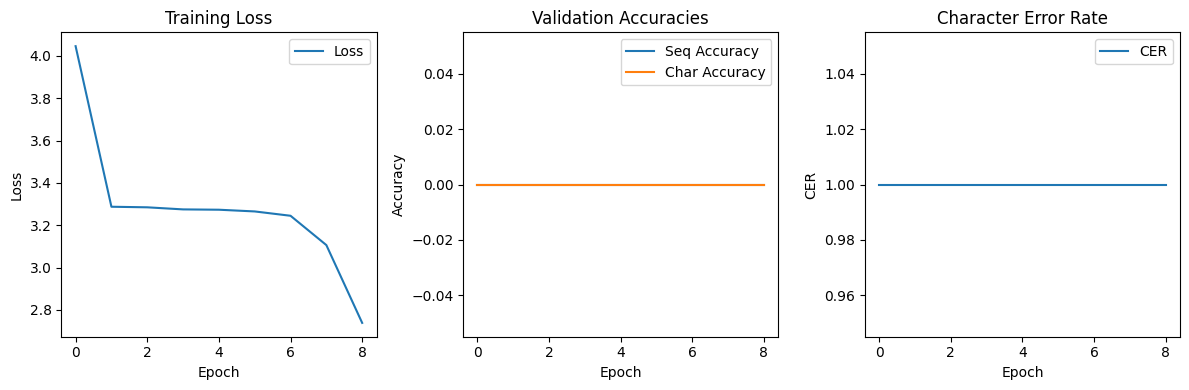

Epoch 10/15 | Loss: 2.2175
Validation set size: 103

Sample predictions:
GT: W8BNX | Pred: D
GT: E46PD | Pred: 48PD
GT: 4YC85 | Pred: 4Y8
GT: D7EN3 | Pred: 
GT: B35F6 | Pred: 48
Validation Sequence Accuracy: 0.0000
Validation Character Accuracy: 0.0800
Validation CER: 0.7600


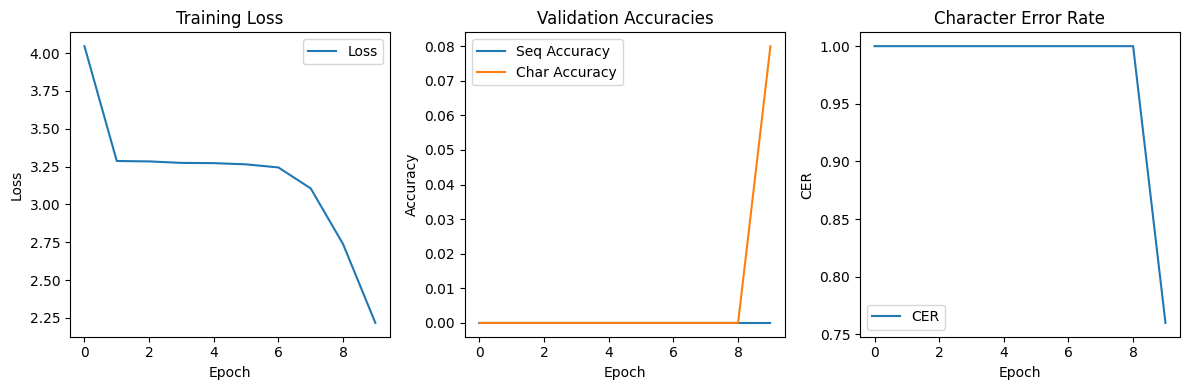

Epoch 11/15 | Loss: 1.2435
Validation set size: 103

Sample predictions:
GT: P7FYP | Pred: P7FYP
GT: N7EBX | Pred: N7EBX
GT: CM6YB | Pred: CN6YB
GT: FYFBN | Pred: FYFBN
GT: Y48C3 | Pred: Y48C3
Validation Sequence Accuracy: 0.8000
Validation Character Accuracy: 0.9600
Validation CER: 0.0400


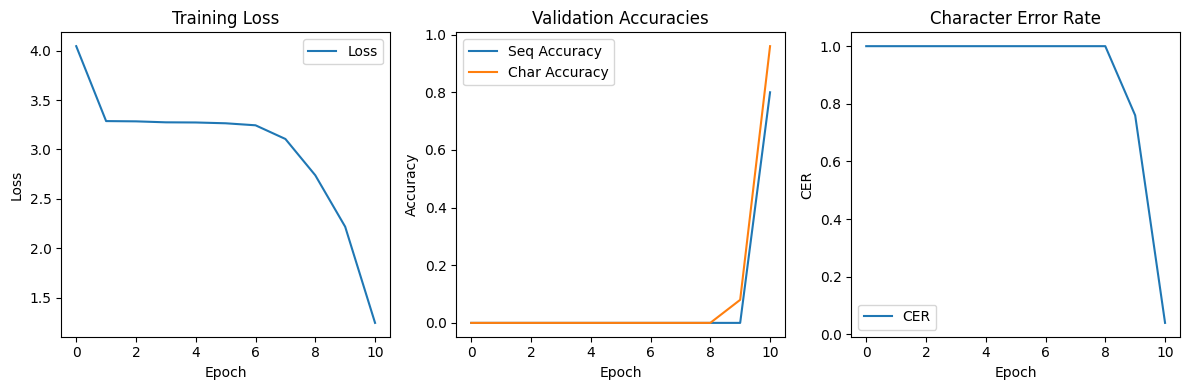

Epoch 12/15 | Loss: 0.5008
Validation set size: 103

Sample predictions:
GT: YDG8N | Pred: YDG8N
GT: 8NPD5 | Pred: 8NPD5
GT: NBMX7 | Pred: NBMW7
GT: X3DEB | Pred: X3DEB
GT: NDME7 | Pred: NDME7
Validation Sequence Accuracy: 0.8000
Validation Character Accuracy: 0.9600
Validation CER: 0.0400


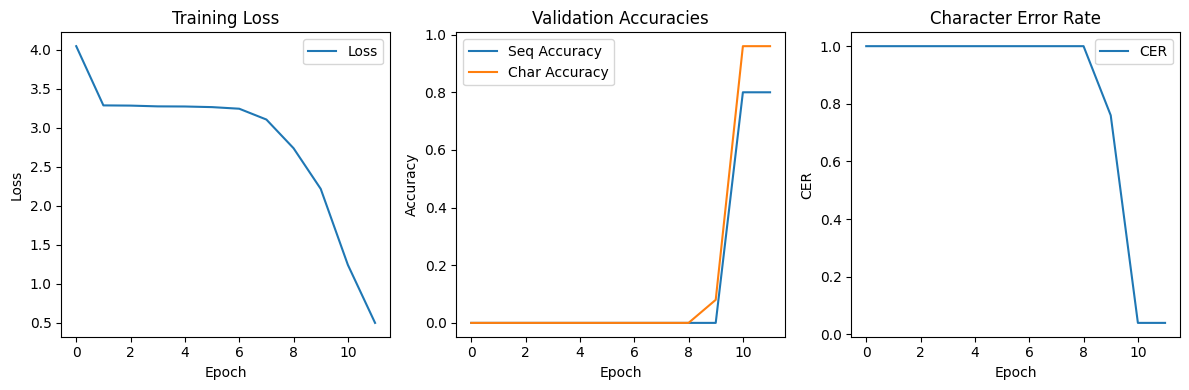

Epoch 13/15 | Loss: 0.2370
Validation set size: 103

Sample predictions:
GT: G3DY6 | Pred: G3DY6
GT: NXC83 | Pred: NXC83
GT: BW6N6 | Pred: B6N6
GT: FYFBN | Pred: FYFBN
GT: C6F8G | Pred: C6F8G
Validation Sequence Accuracy: 0.8000
Validation Character Accuracy: 0.8400
Validation CER: 0.0400


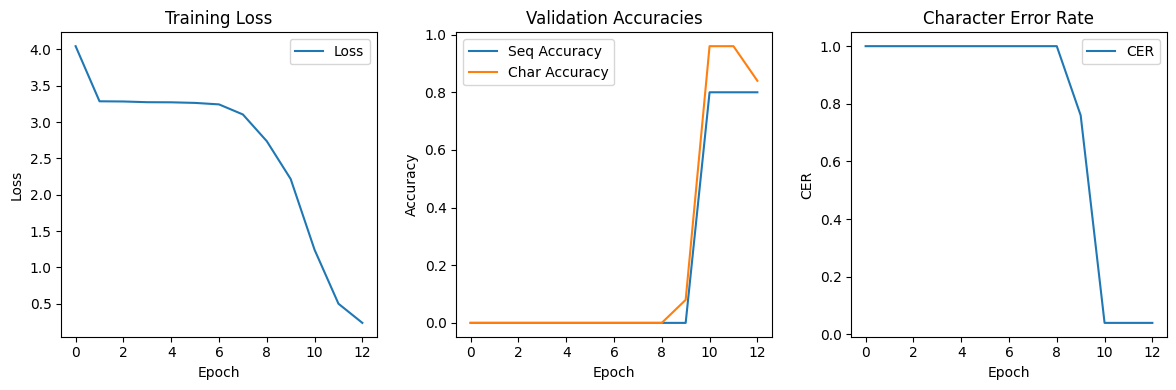

Epoch 14/15 | Loss: 0.1241
Validation set size: 103

Sample predictions:
GT: N8PFE | Pred: N8PFE
GT: CM6YB | Pred: CM6YB
GT: NEGGN | Pred: NEGGN
GT: 5NPDN | Pred: 5NPDN
GT: 77WP4 | Pred: 77WP4
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


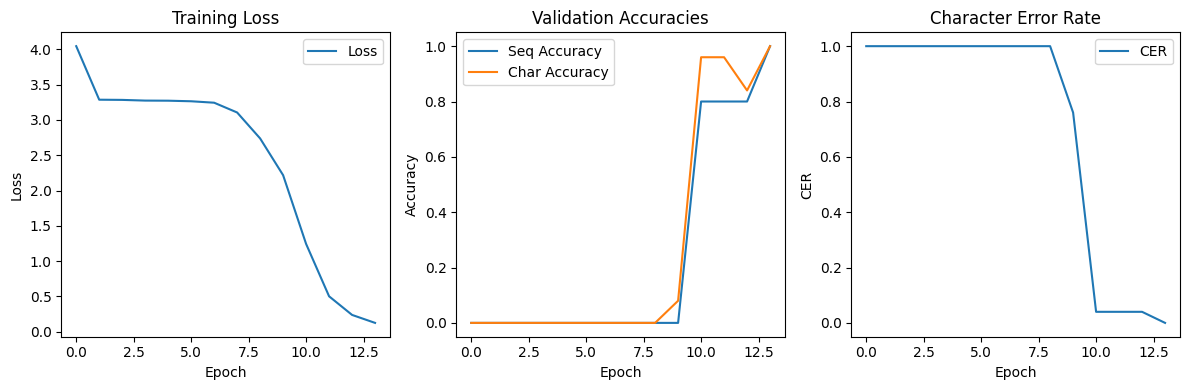

Epoch 15/15 | Loss: 0.0661
Validation set size: 103

Sample predictions:
GT: NB45D | Pred: NB45D
GT: 7FDE7 | Pred: 7FDC7
GT: W4CDC | Pred: W4EDC
GT: 5WDDW | Pred: 5WDDW
GT: 3D7BD | Pred: 3D7BD
Validation Sequence Accuracy: 0.6000
Validation Character Accuracy: 0.9200
Validation CER: 0.0800


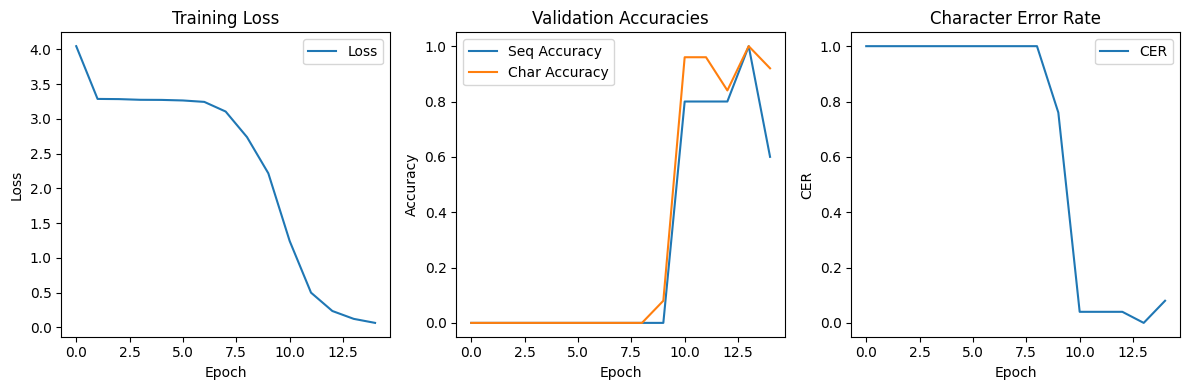

In [8]:
def train_model(model, train_loader, val_loader, idx2char, epochs=3, device="cpu"):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            log_probs = logits.log_softmax(2).permute(1, 0, 2)
            input_lengths = torch.full((images.size(0),), logits.size(1), dtype=torch.long)
            target_lengths = torch.full((labels.size(0),), labels.size(1), dtype=torch.long)

            loss = criterion(log_probs, labels, input_lengths, target_lengths)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")
        print("Validation set size:", len(val_loader.dataset))

        # Validation sample
        model.eval()
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images = val_images.to(device)
                logits = model(val_images)
                decoded = ctc_greedy_decoder(logits, idx2char)

                # Compute accuracies
                seq_acc = sequence_accuracy(decoded, val_labels, idx2char)
                cer_score = cer(decoded, val_labels, idx2char)
                char_acc = char_accuracy(decoded, val_labels, idx2char)

                print("\nSample predictions:")
                for i in range(min(5, len(decoded))):
                    gt = "".join([idx2char[c.item()] for c in val_labels[i] if c.item() != 0])
                    print(f"GT: {gt} | Pred: {decoded[i]}")
                break

        print(f"Validation Sequence Accuracy: {seq_acc:.4f}")
        print(f"Validation Character Accuracy: {char_acc:.4f}")
        print(f"Validation CER: {cer_score:.4f}")

        # Save metrics for plotting
        if 'history' not in globals():
            global history
            history = {'loss': [], 'seq_acc': [], 'char_acc': [], 'cer': []}
        history['loss'].append(avg_loss)
        history['seq_acc'].append(seq_acc)
        history['char_acc'].append(char_acc)
        history['cer'].append(cer_score)

        # Plotting
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.plot(history['loss'], label='Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(history['seq_acc'], label='Seq Accuracy')
        plt.plot(history['char_acc'], label='Char Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Validation Accuracies')
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(history['cer'], label='CER')
        plt.xlabel('Epoch')
        plt.ylabel('CER')
        plt.title('Character Error Rate')
        plt.legend()

        plt.tight_layout()
        plt.show()


# Run training
train_model(model, train_loader, val_loader, idx2char, epochs=15, device=device)


In [9]:
def train_model(model, train_loader, val_loader, idx2char, epochs=15, device="cpu"):
    model.to(device)
    criterion = nn.CTCLoss(blank=0, zero_infinity=True)  # adjust blank idx if different
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # 🔥 Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-3,  # peak LR
        steps_per_epoch=len(train_loader),
        epochs=epochs
    )

    # For plotting later
    history = {'loss': [], 'seq_acc': [], 'char_acc': [], 'cer': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            log_probs = logits.log_softmax(2).permute(1, 0, 2)
            input_lengths = torch.full((images.size(0),), logits.size(1), dtype=torch.long)
            target_lengths = torch.full((labels.size(0),), labels.size(1), dtype=torch.long)

            loss = criterion(log_probs, labels, input_lengths, target_lengths)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()   # 🔥 update LR each batch

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        current_lr = scheduler.get_last_lr()[0]

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")
        print("Validation set size:", len(val_loader.dataset))

        # Validation
        model.eval()
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images = val_images.to(device)
                logits = model(val_images)
                decoded = ctc_greedy_decoder(logits, idx2char)

                # Compute metrics
                seq_acc = sequence_accuracy(decoded, val_labels, idx2char)
                cer_score = cer(decoded, val_labels, idx2char)
                char_acc = char_accuracy(decoded, val_labels, idx2char)

                print("\nSample predictions:")
                for i in range(min(5, len(decoded))):
                    gt = "".join([idx2char[c.item()] for c in val_labels[i] if c.item() != 0])
                    print(f"GT: {gt} | Pred: {decoded[i]}")
                break

        print(f"Validation Sequence Accuracy: {seq_acc:.4f}")
        print(f"Validation Character Accuracy: {char_acc:.4f}")
        print(f"Validation CER: {cer_score:.4f}")

        # Save metrics
        history['loss'].append(avg_loss)
        history['seq_acc'].append(seq_acc)
        history['char_acc'].append(char_acc)
        history['cer'].append(cer_score)

        # Plot after each epoch
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.plot(history['loss'], label='Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss'); plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(history['seq_acc'], label='Seq Accuracy')
        plt.plot(history['char_acc'], label='Char Accuracy')
        plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation Accuracies'); plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(history['cer'], label='CER')
        plt.xlabel('Epoch'); plt.ylabel('CER'); plt.title('Character Error Rate'); plt.legend()

        plt.tight_layout()
        plt.show()


Epoch 1/15 | Loss: 0.0388 | LR: 0.000153
Validation set size: 103

Sample predictions:
GT: GFP54 | Pred: DFP54
GT: CCN2X | Pred: CCN2X
GT: ECD4W | Pred: ECD4W
GT: 3BX86 | Pred: 3BX86
GT: 34PCN | Pred: 34PCW
Validation Sequence Accuracy: 0.6000
Validation Character Accuracy: 0.9200
Validation CER: 0.0800


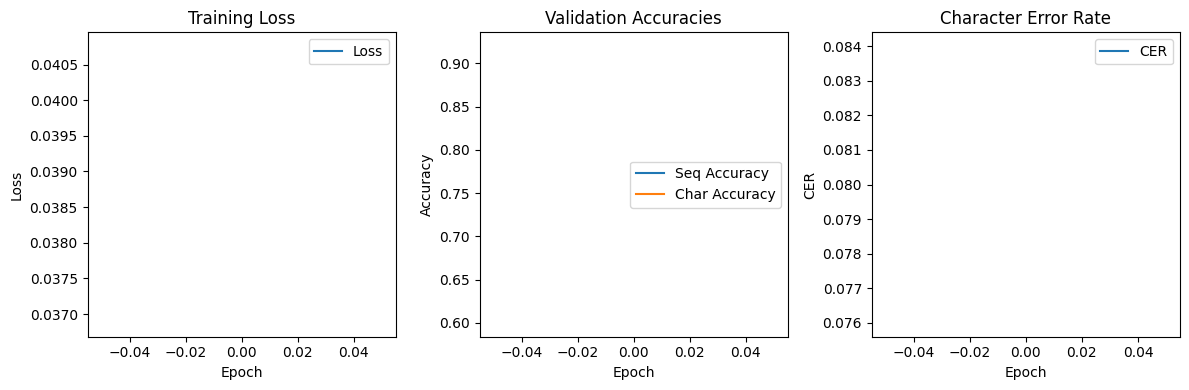

Epoch 2/15 | Loss: 0.0288 | LR: 0.000439
Validation set size: 103

Sample predictions:
GT: 7B4BM | Pred: 7B4BM
GT: N7ENN | Pred: N7ENN
GT: MX8BB | Pred: MX8BB
GT: GCX6F | Pred: GCX6F
GT: CCN2X | Pred: CCN2X
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


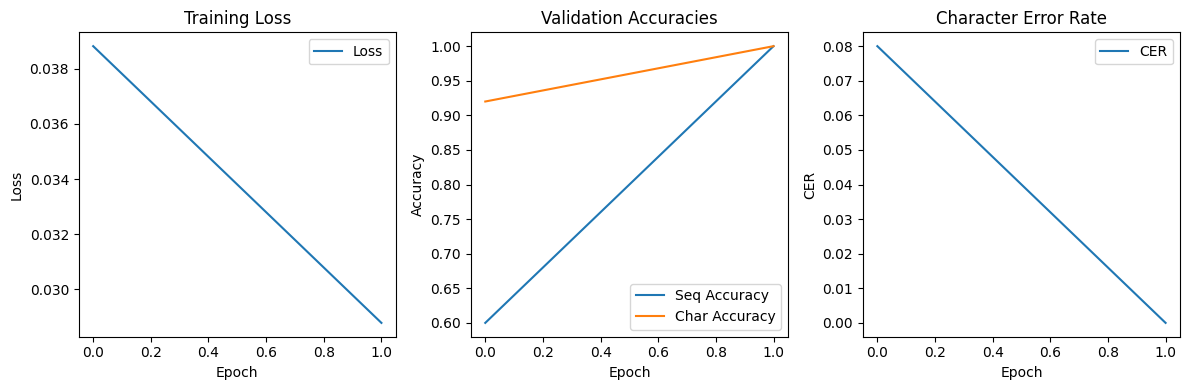

Epoch 3/15 | Loss: 0.0219 | LR: 0.000763
Validation set size: 103

Sample predictions:
GT: 4N2YG | Pred: 4N2YG
GT: 268G2 | Pred: 268G2
GT: 55Y2M | Pred: 55Y2M
GT: NXCMN | Pred: NXCMN
GT: 3X5FM | Pred: 3X5FM
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


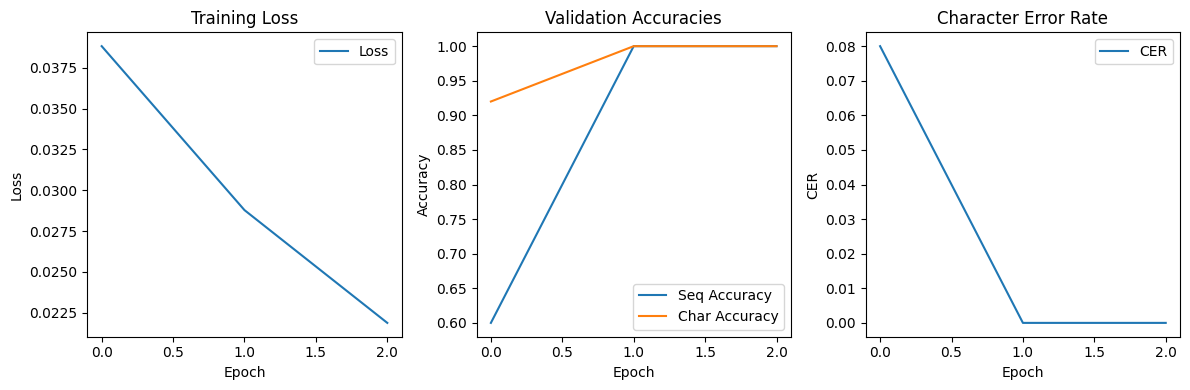

Epoch 4/15 | Loss: 0.0168 | LR: 0.000973
Validation set size: 103

Sample predictions:
GT: B5PNN | Pred: B5PNN
GT: YCMCW | Pred: YCMCW
GT: 4N2YG | Pred: 4N2YG
GT: ENN7N | Pred: 7ENN7N
GT: MX8BB | Pred: MX8BB
Validation Sequence Accuracy: 0.8000
Validation Character Accuracy: 0.8077
Validation CER: 0.0400


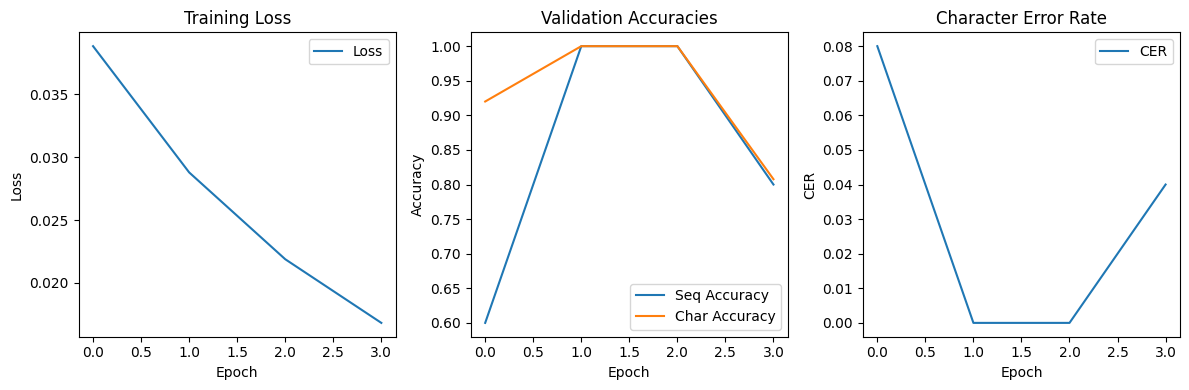

Epoch 5/15 | Loss: 0.0121 | LR: 0.000994
Validation set size: 103

Sample predictions:
GT: 5GCD3 | Pred: 5GCD3
GT: 63PXE | Pred: 63PXE
GT: 5NPDN | Pred: 5NPDN
GT: C6F8G | Pred: E6F8G
GT: 4F8YP | Pred: 4F8YP
Validation Sequence Accuracy: 0.8000
Validation Character Accuracy: 0.9600
Validation CER: 0.0400


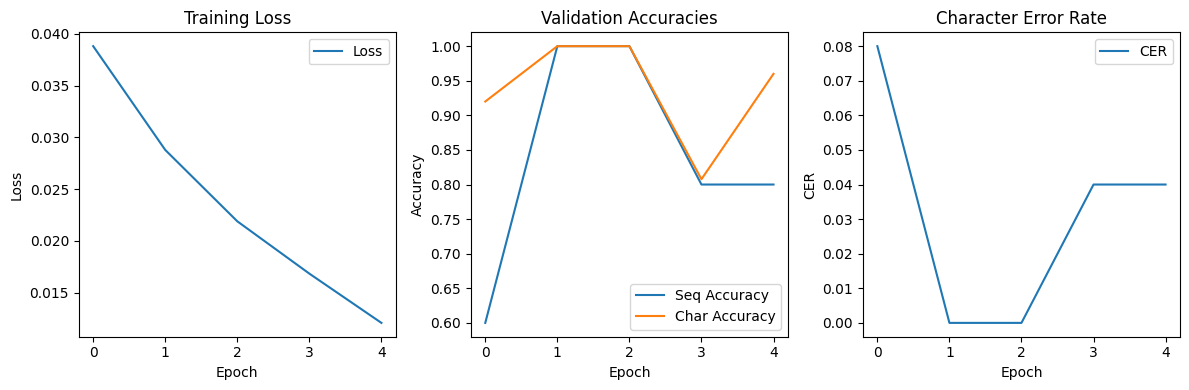

Epoch 6/15 | Loss: 0.0039 | LR: 0.000949
Validation set size: 103

Sample predictions:
GT: C6F8G | Pred: E6F8G
GT: W8BNX | Pred: W8BNX
GT: YDG8N | Pred: YDG8N
GT: YCMCW | Pred: YCMEW
GT: CFP86 | Pred: CFP86
Validation Sequence Accuracy: 0.6000
Validation Character Accuracy: 0.9200
Validation CER: 0.0800


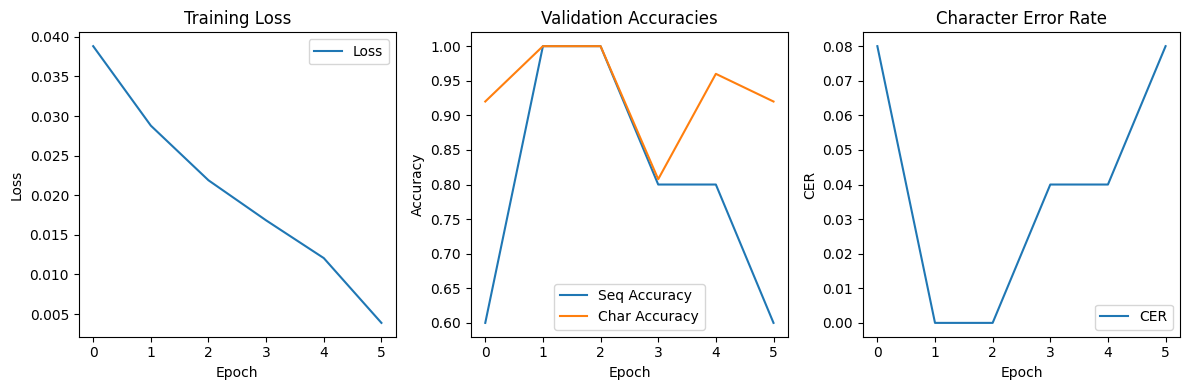

Epoch 7/15 | Loss: 0.0015 | LR: 0.000865
Validation set size: 103

Sample predictions:
GT: GWNM6 | Pred: GWNM6
GT: E46PD | Pred: E46PD
GT: 3X5FM | Pred: 3X5FM
GT: CG5DD | Pred: CG5DD
GT: N8PFE | Pred: N8PFE
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


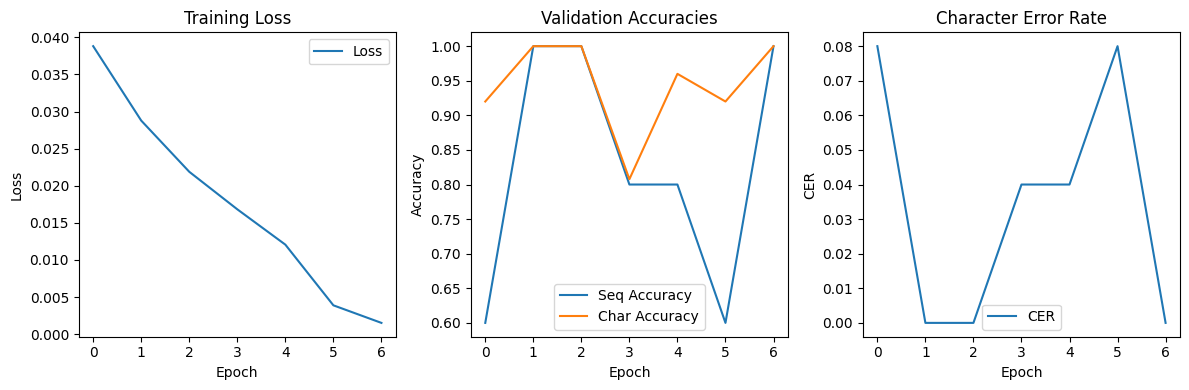

Epoch 8/15 | Loss: 0.0011 | LR: 0.000748
Validation set size: 103

Sample predictions:
GT: CFP86 | Pred: CFP86
GT: YCNFC | Pred: YCNFC
GT: DD764 | Pred: DD764
GT: W4CDC | Pred: W4CDC
GT: X3DEB | Pred: X3DEB
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


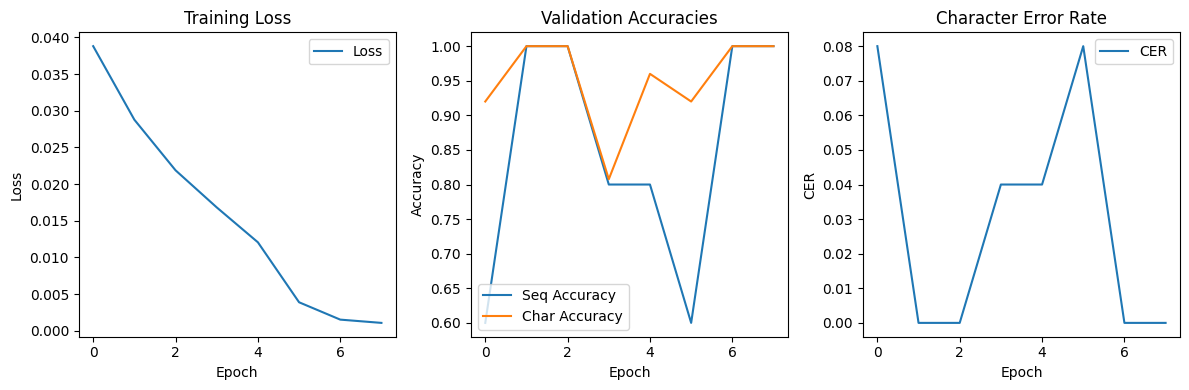

Epoch 9/15 | Loss: 0.0009 | LR: 0.000609
Validation set size: 103

Sample predictions:
GT: 7B4BM | Pred: 7B4BM
GT: 8WY7D | Pred: 8WY7D
GT: NB45D | Pred: NB45D
GT: M67B3 | Pred: M6B3
GT: 7GMF3 | Pred: 7GMF3
Validation Sequence Accuracy: 0.8000
Validation Character Accuracy: 0.8800
Validation CER: 0.0400


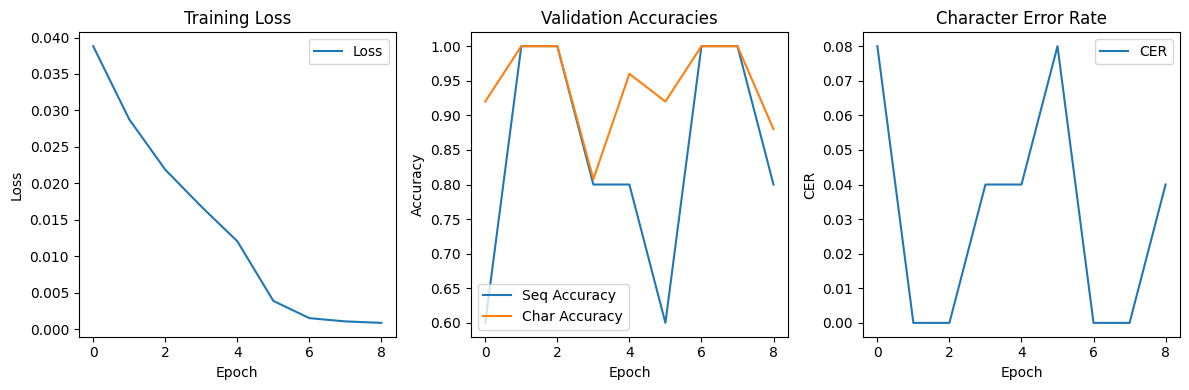

Epoch 10/15 | Loss: 0.0007 | LR: 0.000460
Validation set size: 103

Sample predictions:
GT: NFD8G | Pred: NFD8G
GT: BW5YM | Pred: BW5YM
GT: 4YCEX | Pred: 4YCCX
GT: W4CDC | Pred: W4CDC
GT: CFP86 | Pred: CFP86
Validation Sequence Accuracy: 0.8000
Validation Character Accuracy: 0.9600
Validation CER: 0.0400


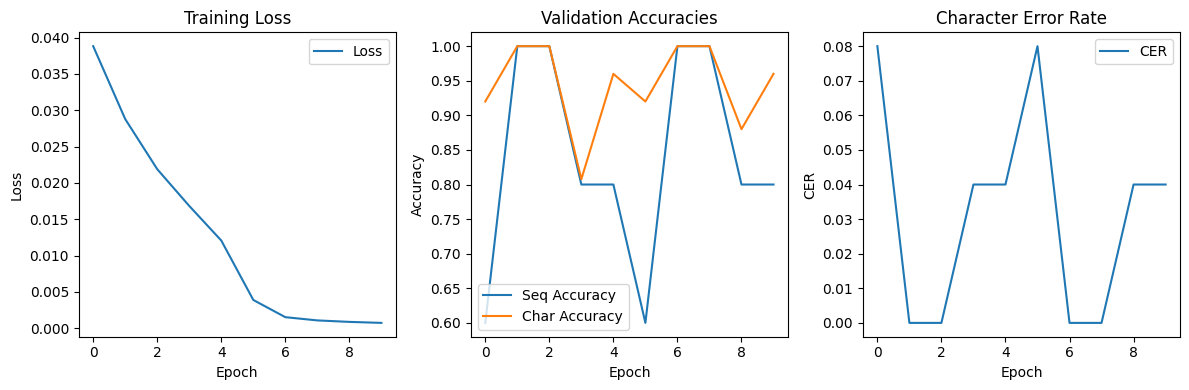

Epoch 11/15 | Loss: 0.0006 | LR: 0.000315
Validation set size: 103

Sample predictions:
GT: CM6YB | Pred: CM6YB
GT: M5YM2 | Pred: M5YM2
GT: 5MF7C | Pred: 5MF7C
GT: P4PDE | Pred: P4PDE
GT: G3DY6 | Pred: G3DY6
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


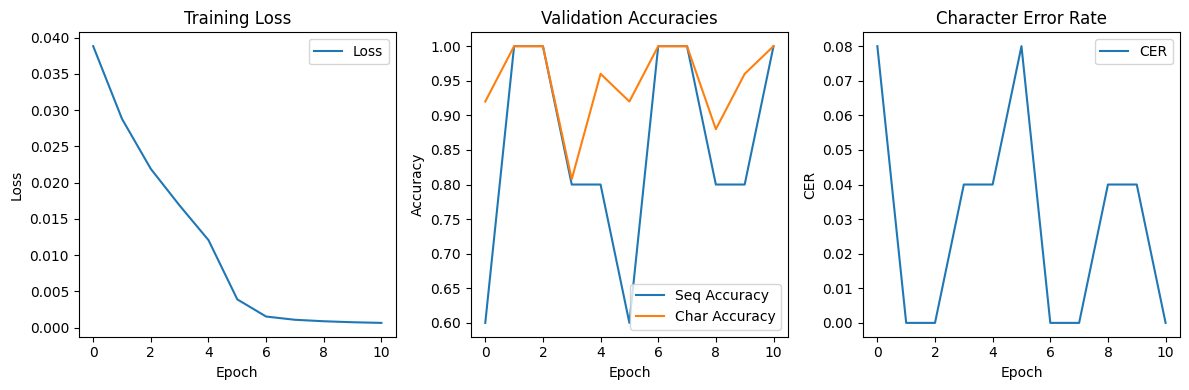

Epoch 12/15 | Loss: 0.0006 | LR: 0.000186
Validation set size: 103

Sample predictions:
GT: MX8BB | Pred: MX8BB
GT: PDYC8 | Pred: PDYC8
GT: CDFEN | Pred: CDFEN
GT: CCN2X | Pred: CCN2X
GT: GCX6F | Pred: GCX6F
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


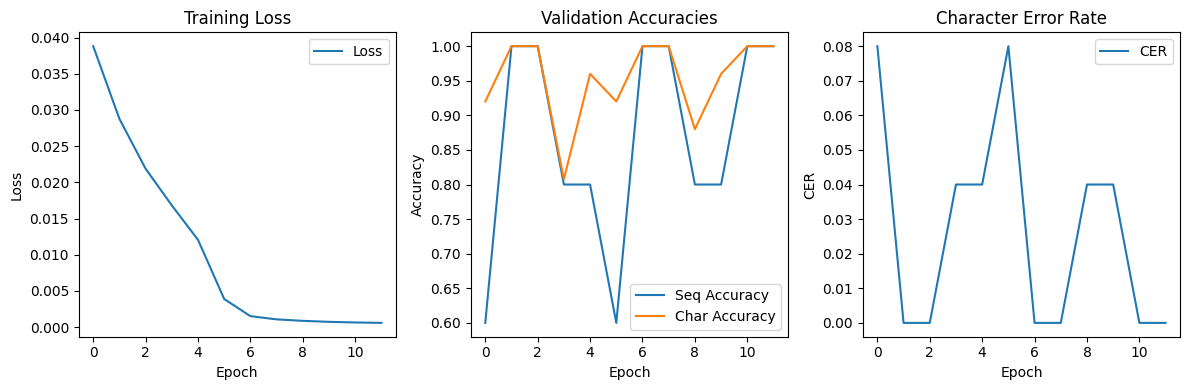

Epoch 13/15 | Loss: 0.0006 | LR: 0.000085
Validation set size: 103

Sample predictions:
GT: ENN7N | Pred: ENN7N
GT: D7EN3 | Pred: D7EN3
GT: EPPG3 | Pred: EPPG3
GT: MN5C4 | Pred: MN5C4
GT: 7GMF3 | Pred: 7GMF3
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


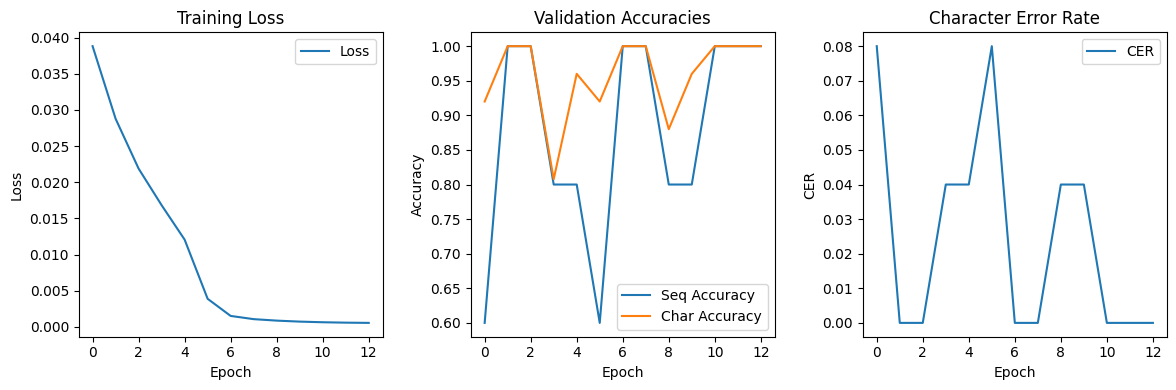

Epoch 14/15 | Loss: 0.0005 | LR: 0.000021
Validation set size: 103

Sample predictions:
GT: GCX6F | Pred: GCX6F
GT: NE325 | Pred: NE325
GT: D7EN3 | Pred: D7EN3
GT: NXC83 | Pred: NXC83
GT: B84XC | Pred: B84XC
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


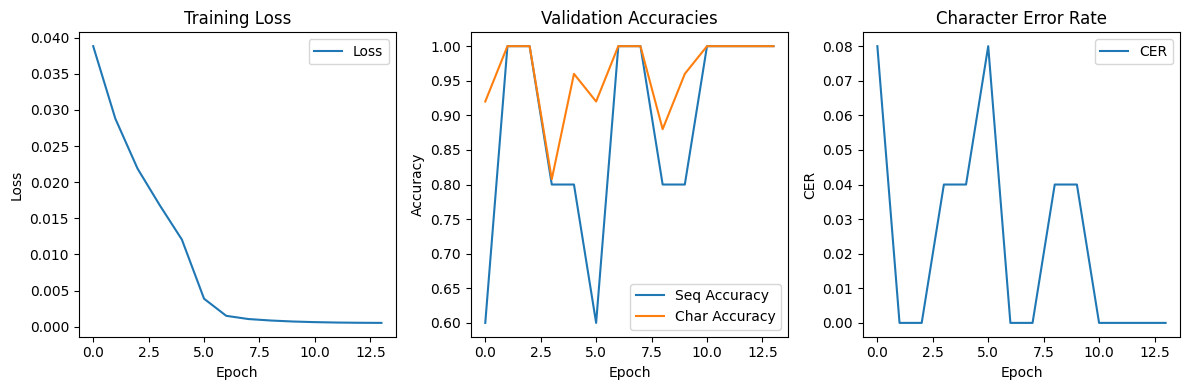

Epoch 15/15 | Loss: 0.0005 | LR: 0.000000
Validation set size: 103

Sample predictions:
GT: P7FYP | Pred: P7FYP
GT: B35F6 | Pred: B35F6
GT: W8BNX | Pred: W8BNX
GT: 63PXE | Pred: 63PXE
GT: W4CDC | Pred: W4CDC
Validation Sequence Accuracy: 1.0000
Validation Character Accuracy: 1.0000
Validation CER: 0.0000


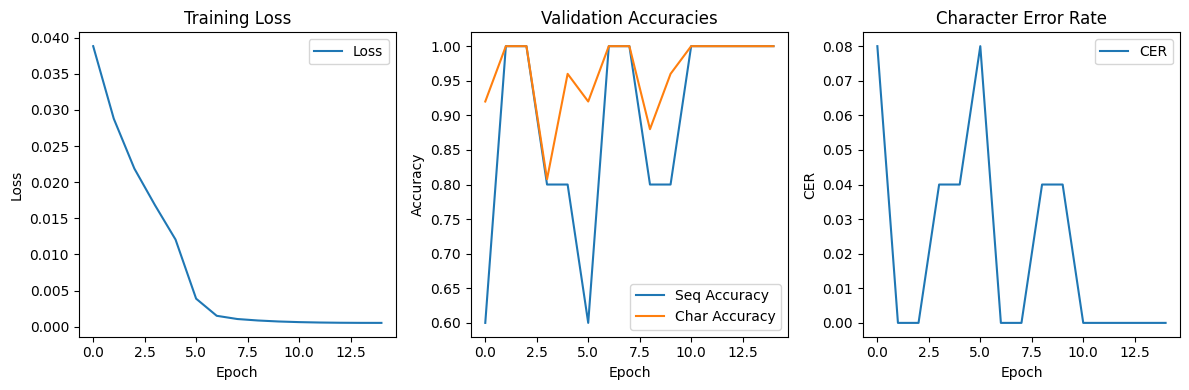

In [10]:
train_model(model, train_loader, val_loader, idx2char, epochs=15, device=device)